# 08 -- Sprawnosc generatora i straty elektryczne

Ten notebook przedstawia modele strat elektrycznych w EW:

1. **Generator** -- model strat miedzio-zelaznych eta_g(P/P_n)
2. **Transformator** -- straty jałowe i obciazeniowe (opcjonalny)
3. **Potrzeby wlasne** -- zuzycie energii na cele wlasne elektrowni
4. **Sprawnosc calkowita elektryczna** -- zlozenie modeli

Modele zaimplementowane w module `src/generator.py`.

---

> **Notebook OPCJONALNY** — `compute_power()` w **nb 10** używa domyślnych
> współczynników $k_{Cu}=0{,}025$, $k_{Fe}=0{,}010$, $k_{mech}=0{,}005$
> (typowe dla generatora ~500 kW). Cały łańcuch integracyjny działa bez
> tego materiału — z **zmienną** sprawnością $\eta_g(P/P_n)$, a nie ze stałą
> $\eta_g = 0{,}96$ jak w nb 05.
>
> **Po co go czytać?** Żeby zrozumieć **dlaczego** $\eta_g$ spada przy niskim
> obciążeniu, **gdzie** jest maksimum sprawności (przy ~75-80% $P_n$, nie 100%),
> i **jak** współczynniki zmieniają się z wielkością maszyny
> (50 kW → 5 MW).

---

## Modul `src/generator.py`

**Prompt do LLM tworzacy ten modul:**
> *"Stworz modul src/generator.py do modelowania strat generatora EW.
> Funkcja `generator_efficiency(P_ratio, k_cu, k_fe, k_mech)` -- model strat:
> miedziane (∝ P²), zelazne (stale), mechaniczne (stale).
> Dodatkowo `generator_efficiency_peak()` zwraca punkt optymalny."*

**Funkcje w module:**
- `generator_efficiency(P_ratio, k_cu, k_fe, k_mech)` -- sprawnosc generatora
- `generator_efficiency_peak(k_cu, k_fe, k_mech)` -- punkt optymalny

**Uwaga didaktyczna:** model transformatora i potrzeb wlasnych nie znajduje
sie w module — pokazujemy je **w samym notebooku** jako "dodatkowe rozszerzenia"
o tej samej strukturze co generator. To rozjasnia, ze sa to wariacje tego samego
wzoru ($P_{strat} = k \cdot (P/P_n)^a$), a nie nowe, niezalezne abstrakcje.

## Konfiguracja

**Prompt do LLM:**
> *"Napisz kod konfiguracji notebooka: zaladuj `generator_efficiency` i
> `generator_efficiency_peak` z `src/generator`. Zdefiniuj inline pomocnicze
> funkcje `transformer_efficiency` (kopia struktury generatora bez czlonu mech.)
> i `auxiliary_power` (stale + procentowe zapotrzebowanie wlasne)."*

**Uzyte moduly/funkcje:** `src.generator`: generator_efficiency, generator_efficiency_peak; inline: transformer_efficiency, auxiliary_power.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from src.generator import generator_efficiency, generator_efficiency_peak

# === Pomocnicze modele (inline) ===
# Te modele maja te sama strukture co generator (kwadratowe straty obciazeniowe
# + stale straty jalowe). Trzymamy je w notebooku, a nie w module — zeby podkreslic
# wspolny wzor i unikac mnozenia abstrakcji.

def transformer_efficiency(P_ratio, k_cu=0.010, k_fe=0.005):
    """Sprawnosc transformatora: eta = P / (P + k_cu·P² + k_fe), w jednostkach P_n."""
    P_ratio = np.asarray(P_ratio, dtype=float)
    loss = k_cu * P_ratio**2 + k_fe
    eta = np.where(P_ratio > 0, P_ratio / (P_ratio + loss), 0.0)
    return np.clip(eta, 0.0, 1.0)


def auxiliary_power(P_rated_kW, aux_fraction=0.02, aux_fixed_kW=5.0):
    """Potrzeby wlasne EW [kW]: P_aux = P_stale + k_aux · P_n."""
    return aux_fixed_kW + aux_fraction * P_rated_kW


def electrical_efficiency(P_ratio, include_trafo=True):
    """eta_elektryczna = eta_gen · eta_trafo (lub samego generatora gdy trafo brak)."""
    eta_g = generator_efficiency(P_ratio)
    if include_trafo:
        eta_t = transformer_efficiency(P_ratio)
        return eta_g * eta_t
    return eta_g


P_ratio = np.linspace(0.01, 1.2, 300)
print('Modul zaladowany. Modele transformatora i potrzeb wlasnych zdefiniowane w notebooku.')

Modul zaladowany. Modele transformatora i potrzeb wlasnych zdefiniowane w notebooku.


---
## Krok 1: Model sprawnosci generatora

Straty w generatorze synchronicznym skladaja sie z trzech komponentow:

$$\eta_g = \frac{P}{P + \Delta P_{Cu} + \Delta P_{Fe} + \Delta P_{mech}}$$

gdzie (wyrazone jako ulamki mocy znamionowej $P_n$):

| Skladnik | Wzor | Charakter | Typowe wartosci |
|----------|------|-----------|----------------|
| $\Delta P_{Cu}$ | $k_{Cu} \cdot (P/P_n)^2$ | Rosnie z obciazeniem ($\sim I^2 R$) | 1.5--3.5% |
| $\Delta P_{Fe}$ | $k_{Fe}$ | Stale (histereza + prady wirowe) | 0.5--1.5% |
| $\Delta P_{mech}$ | $k_{mech}$ | Stale (lozyska, wentylacja) | 0.3--0.8% |

**Sprawnosc maksymalna** wystepuje gdy straty zmienne = straty stale:

$$P_{opt}/P_n = \sqrt{\frac{k_{Fe} + k_{mech}}{k_{Cu}}}$$

**Prompt do LLM:**
> *"Narysuj krzywe sprawnosci generatora dla 3 zestawow parametrow:
> (1) maly generator (k_cu=0.035, k_fe=0.012, k_mech=0.008),
> (2) sredni (domyslne), (3) duzy/nowoczesny (k_cu=0.015, k_fe=0.005, k_mech=0.003).
> Zaznacz punkt optymalny dla kazdego."*

**Uzyte funkcje:** `generator_efficiency()`, `generator_efficiency_peak()`

Maly generator: eta_max=0.9497 przy P/Pn=75.6%, eta(100%)=0.9479
Sredni (domyslny): eta_max=0.9627 przy P/Pn=77.5%, eta(100%)=0.9615
Duzy/nowoczesny: eta_max=0.9786 przy P/Pn=73.0%, eta(100%)=0.9775


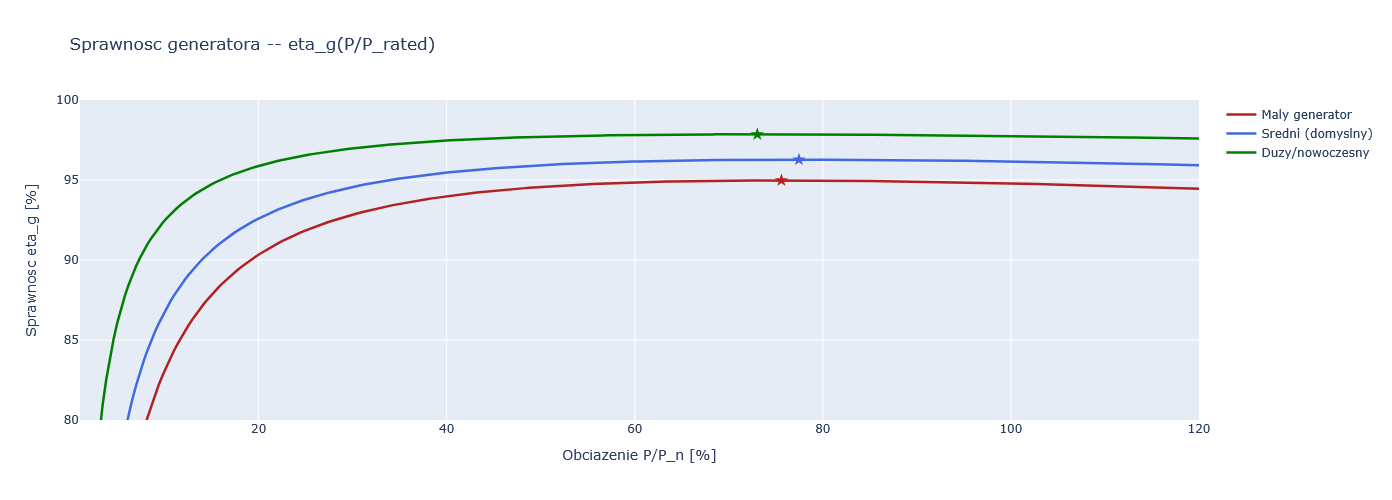

In [2]:
configs = [
    ('Maly generator', 0.035, 0.012, 0.008, 'firebrick'),
    ('Sredni (domyslny)', 0.025, 0.010, 0.005, 'royalblue'),
    ('Duzy/nowoczesny', 0.015, 0.005, 0.003, 'green'),
]

fig = go.Figure()
for label, k_cu, k_fe, k_mech, color in configs:
    eta = generator_efficiency(P_ratio, k_cu, k_fe, k_mech)
    P_opt, eta_max = generator_efficiency_peak(k_cu, k_fe, k_mech)
    eta_full = float(generator_efficiency(1.0, k_cu, k_fe, k_mech))

    fig.add_trace(go.Scatter(
        x=P_ratio * 100, y=eta * 100,
        mode='lines', name=label,
        line=dict(color=color, width=2.5),
    ))
    # Mark peak
    fig.add_trace(go.Scatter(
        x=[P_opt * 100], y=[eta_max * 100],
        mode='markers', showlegend=False,
        marker=dict(color=color, size=10, symbol='star'),
    ))
    print(f'{label}: eta_max={eta_max:.4f} przy P/Pn={P_opt:.1%}, eta(100%)={eta_full:.4f}')

fig.update_layout(
    title='Sprawnosc generatora -- eta_g(P/P_rated)',
    xaxis_title='Obciazenie P/P_n [%]',
    yaxis_title='Sprawnosc eta_g [%]',
    yaxis_range=[80, 100],
    height=500, hovermode='x unified',
)
fig.show()

### Rozklad strat generatora

**Prompt do LLM:**
> *"Pokaz jak straty Cu, Fe i mech. zmieniaja sie z obciazeniem (warstwowo, fill).
> Uzyj k_cu=0.025, k_fe=0.010, k_mech=0.005."*

**Uzyte funkcje:** inline (rozkladowi przyswiadcza tylko numpy)

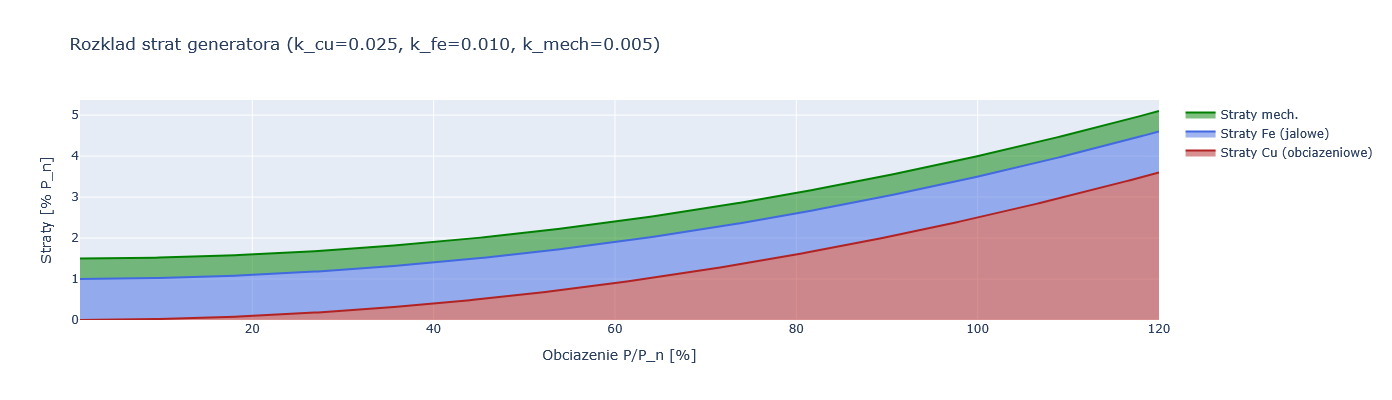

In [3]:
k_cu, k_fe, k_mech = 0.025, 0.010, 0.005

loss_cu = k_cu * P_ratio**2 * 100    # %
loss_fe = np.full_like(P_ratio, k_fe * 100)
loss_mech = np.full_like(P_ratio, k_mech * 100)

fig = go.Figure()
fig.add_trace(go.Scatter(x=P_ratio*100, y=loss_cu, mode='lines',
    name='Straty Cu (obciazeniowe)', fill='tozeroy',
    line=dict(color='firebrick')))
fig.add_trace(go.Scatter(x=P_ratio*100, y=loss_cu + loss_fe, mode='lines',
    name='Straty Fe (jalowe)', fill='tonexty',
    line=dict(color='royalblue')))
fig.add_trace(go.Scatter(x=P_ratio*100, y=loss_cu + loss_fe + loss_mech, mode='lines',
    name='Straty mech.', fill='tonexty',
    line=dict(color='green')))

fig.update_layout(
    title='Rozklad strat generatora (k_cu=0.025, k_fe=0.010, k_mech=0.005)',
    xaxis_title='Obciazenie P/P_n [%]',
    yaxis_title='Straty [% P_n]',
    height=400, hovermode='x unified',
)
fig.show()

---
## Krok 2: Transformator (opcjonalny)

Transformator podwyzszajacy napiecie ma analogiczna strukture strat:

$$\eta_{tr} = \frac{P}{P + k_{Cu,tr} \cdot (P/P_n)^2 + k_{Fe,tr}}$$

Straty transformatora sa mniejsze niz generatora (brak czesci ruchomych):
- $k_{Cu,tr}$ = 0.8--1.5%
- $k_{Fe,tr}$ = 0.3--0.8%

Transformator jest **opcjonalny** w modelu -- nie kazda EW go wymaga
(np. przy niskim napieciu i krotkim przesyle).

**Prompt do LLM:**
> *"Narysuj sprawnosc generatora, transformatora i ich zlozenia w funkcji obciazenia.
> Zaznacz na wykresie wartosci przy 100% obciazenia."*

**Uzyte funkcje:** `generator_efficiency()` z `src.generator`; inline `transformer_efficiency`, `electrical_efficiency`.

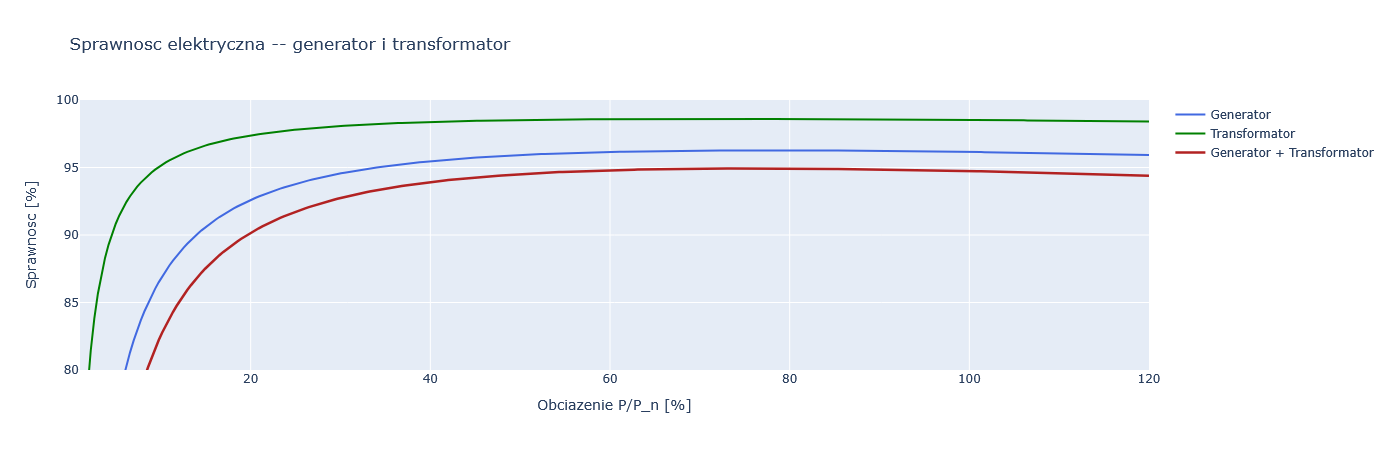

Przy pelnym obciazeniu:
  Generator:     96.2%
  Transformator: 98.5%
  Lacznie:       94.7%


In [4]:
eta_g = generator_efficiency(P_ratio)
eta_t = transformer_efficiency(P_ratio)
eta_both = electrical_efficiency(P_ratio, include_trafo=True)
eta_no_trafo = electrical_efficiency(P_ratio, include_trafo=False)

fig = go.Figure()
fig.add_trace(go.Scatter(x=P_ratio*100, y=eta_g*100, mode='lines',
    name='Generator', line=dict(color='royalblue', width=2)))
fig.add_trace(go.Scatter(x=P_ratio*100, y=eta_t*100, mode='lines',
    name='Transformator', line=dict(color='green', width=2)))
fig.add_trace(go.Scatter(x=P_ratio*100, y=eta_both*100, mode='lines',
    name='Generator + Transformator', line=dict(color='firebrick', width=2.5)))

fig.update_layout(
    title='Sprawnosc elektryczna -- generator i transformator',
    xaxis_title='Obciazenie P/P_n [%]',
    yaxis_title='Sprawnosc [%]',
    yaxis_range=[80, 100],
    height=450, hovermode='x unified',
)
fig.show()

print(f'Przy pelnym obciazeniu:')
print(f'  Generator:     {float(generator_efficiency(1.0)):.1%}')
print(f'  Transformator: {float(transformer_efficiency(1.0)):.1%}')
print(f'  Lacznie:       {float(electrical_efficiency(1.0)):.1%}')

---
## Krok 3: Potrzeby wlasne

Czesc wyprodukowanej energii zuzywa sama elektrownia:

$$P_{aux} = P_{aux,stale} + k_{aux} \cdot P_n$$

Obejmuje: uklady sterowania, chlodzenie, oswietlenie, pompy olejowe, suwnica, itp.

Typowe wartosci:
- $P_{aux,stale}$ = 2--10 kW
- $k_{aux}$ = 1--3% mocy znamionowej

**Prompt do LLM:**
> *"Pokaz potrzeby wlasne dla mocy znamionowej P_n = 50..2000 kW: w kW i w %.
> Wez P_stale = 5 kW, k_aux = 2%."*

**Uzyte funkcje:** inline `auxiliary_power()`

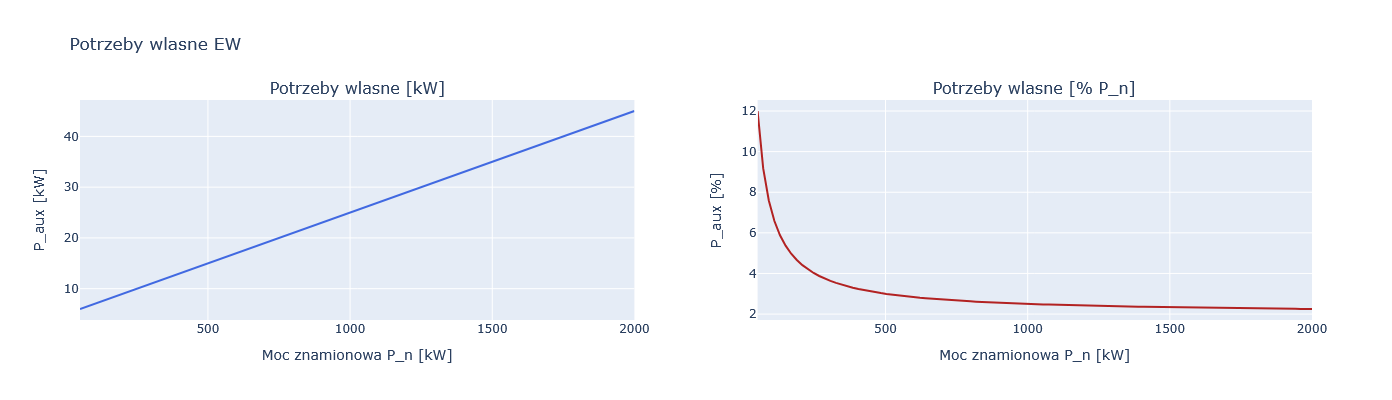

EW 500 kW: potrzeby wlasne = 15.0 kW (3.0%)


In [5]:
P_rated_range = np.linspace(50, 2000, 100)
P_aux = [auxiliary_power(P) for P in P_rated_range]
P_aux_pct = [auxiliary_power(P) / P * 100 for P in P_rated_range]

fig = make_subplots(rows=1, cols=2,
    subplot_titles=['Potrzeby wlasne [kW]', 'Potrzeby wlasne [% P_n]'])

fig.add_trace(go.Scatter(x=P_rated_range, y=P_aux, mode='lines',
    line=dict(color='royalblue', width=2), name='P_aux'), row=1, col=1)
fig.add_trace(go.Scatter(x=P_rated_range, y=P_aux_pct, mode='lines',
    line=dict(color='firebrick', width=2), name='P_aux [%]'), row=1, col=2)

fig.update_xaxes(title_text='Moc znamionowa P_n [kW]', row=1, col=1)
fig.update_xaxes(title_text='Moc znamionowa P_n [kW]', row=1, col=2)
fig.update_yaxes(title_text='P_aux [kW]', row=1, col=1)
fig.update_yaxes(title_text='P_aux [%]', row=1, col=2)
fig.update_layout(height=400, showlegend=False,
    title='Potrzeby wlasne EW')
fig.show()

# Przyklad
P_n = 500
print(f'EW {P_n} kW: potrzeby wlasne = {auxiliary_power(P_n):.1f} kW ({auxiliary_power(P_n)/P_n*100:.1f}%)')

---
## Krok 4: Porownanie z modelem stalym

Notebook 05 zalozyl **stale** sprawnosci czastkowe:
$\eta_t = 0.92$, $\eta_g = 0.96$, $\eta_{wlot} = \eta_{wylot} = 0.98$ →
$\eta_{total} = 0.848$. Tutaj patrzymy tylko na czesc generatorowa
($\eta_g$): nb05 traktuje ja jako **stala 0.96**, model w tym notebooku — jako **zmienna z obciazeniem**.

**Prompt do LLM:**
> *"Porownaj stala sprawnosc generatora η_g = 0.96 (jak w nb05) z modelem zmiennym
> w funkcji obciazenia. Pokaz roznice na wykresie."*

**Uzyte funkcje:** `generator_efficiency()`

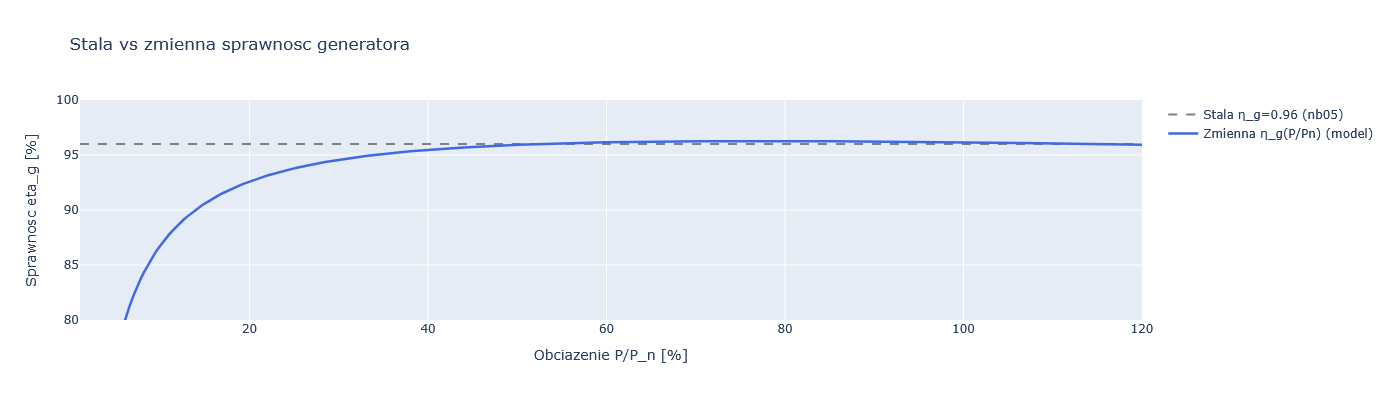

  P/Pn=10%: stala=0.9600, zmienna=0.8677, roznica=+9.23 pp
  P/Pn=30%: stala=0.9600, zmienna=0.9456, roznica=+1.44 pp
  P/Pn=50%: stala=0.9600, zmienna=0.9592, roznica=+0.08 pp
  P/Pn=80%: stala=0.9600, zmienna=0.9627, roznica=-0.27 pp
  P/Pn=100%: stala=0.9600, zmienna=0.9615, roznica=-0.15 pp

Model staly zawyza sprawnosc przy niskich obciazeniach.
Maksymalna sprawnosc zmiennego modelu wystepuje przy obciazeniu ~77% (nie 100%).


In [6]:
eta_const = 0.96  # stala sprawnosc generatora z nb05
eta_var = generator_efficiency(P_ratio)

fig = go.Figure()
fig.add_trace(go.Scatter(x=P_ratio*100, y=np.full_like(P_ratio, eta_const)*100,
    mode='lines', name='Stala η_g=0.96 (nb05)',
    line=dict(color='gray', width=2, dash='dash')))
fig.add_trace(go.Scatter(x=P_ratio*100, y=eta_var*100,
    mode='lines', name='Zmienna η_g(P/Pn) (model)',
    line=dict(color='royalblue', width=2.5)))

fig.update_layout(
    title='Stala vs zmienna sprawnosc generatora',
    xaxis_title='Obciazenie P/P_n [%]',
    yaxis_title='Sprawnosc eta_g [%]',
    yaxis_range=[80, 100],
    height=400, hovermode='x unified',
)
fig.show()

# Roznica jest najwieksza przy niskich obciazeniach (~10-30% Pn)
P_test = np.array([0.10, 0.30, 0.50, 0.80, 1.00])
for p in P_test:
    eta_v = float(generator_efficiency(p))
    print(f'  P/Pn={p:.0%}: stala={eta_const:.4f}, zmienna={eta_v:.4f}, '
          f'roznica={(eta_const - eta_v)*100:+.2f} pp')
print()
print('Model staly zawyza sprawnosc przy niskich obciazeniach.')
print('Maksymalna sprawnosc zmiennego modelu wystepuje przy obciazeniu ~77% (nie 100%).')

---
## Podsumowanie

| Model | Opis | Gdzie? |
|-------|------|--------|
| Generator | $\eta_g(P/P_n) = P/(P + k_{Cu}P^2 + k_{Fe} + k_{mech})$ | `src.generator.generator_efficiency()` |
| Transformator | $\eta_{tr}(P/P_n) = P/(P + k_{Cu}P^2 + k_{Fe})$ | inline w notebooku |
| Potrzeby wlasne | $P_{aux} = P_{stale} + k_{aux} \cdot P_n$ | inline w notebooku |
| Sprawnosc elektryczna | $\eta_g \cdot \eta_{tr}$ | inline w notebooku |

**Kluczowe wnioski:**
- Sprawnosc generatora spada ponizej ~30% obciazenia
- Maksimum sprawnosci jest przy ~75-80% (nie 100%)
- Transformator dodaje dodatkowe ~1.5% strat
- Model staly (nb05) zawyza sprawnosc przy niskim obciazeniu — w nb10 zobaczymy wplyw na produkcje energii.

**Dalej:** notebook 09 -- model kosztow